In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.plot_utils import setup_matplotlib

In [20]:
setup_matplotlib()

In [21]:
experiments = ['square', 'random', 'chirp']
runs = [1, 2, 3, 4]
df_real_dict = {}

for experiment in experiments:
    file_name = f'{experiment}_20251017'
    for run in runs:
        try:
            file_name_real = f'{file_name}_run{run}.csv'
            df_real = pd.read_csv(os.path.join('../data/real/processed/train/', file_name_real))
            # Store dynamically
            df_real_dict[f'{experiment}_run{run}'] = df_real
        except Exception as e:
            print(e)
            continue

In [22]:
from scipy.spatial.transform import Rotation as R

def compute_thrust_signals(df, m=0.045, g=9.81):
    # Normalize quaternion
    quat = df[["qx", "qy", "qz", "qw"]].to_numpy()
    quat /= np.linalg.norm(quat, axis=1, keepdims=True)

    # Transform accel to body frame
    ag_wf = df[["ax", "ay", "az"]].to_numpy()
    r = R.from_quat(quat)
    ag_bf = r.apply(ag_wf, inverse=True)

    df[["ax_body", "ay_body", "az_body"]] = ag_bf

    # IMU-based thrust
    T_bf = m * (ag_bf[:, 2])
    df["T_bf"] = T_bf

    # Motor-based thrust proxy
    motor_cols_rads2 = [c for c in df.columns if c.endswith("_rads2")]
    T_mot = df[motor_cols_rads2].sum(axis=1)
    df["T_mot"] = T_mot

    return df

In [23]:
train_keys = [k for k in df_real_dict.keys() if not k.endswith("4")]
test_keys  = [k for k in df_real_dict.keys() if k.endswith("4")]

print("Training:", train_keys)
print("Testing :", test_keys)

# recompute thrust for all
df_train = []
df_test  = []

for k in train_keys:
    df = compute_thrust_signals(df_real_dict[k].copy())
    df_train.append(df[["T_bf", "T_mot"]])

for k in test_keys:
    df = compute_thrust_signals(df_real_dict[k].copy())
    df_test.append(df[["T_bf", "T_mot"]])

df_train = pd.concat(df_train, ignore_index=True).dropna()
df_test  = pd.concat(df_test, ignore_index=True).dropna()

print("Train samples:", len(df_train))
print("Test samples :", len(df_test))

Training: ['square_run1', 'square_run2', 'square_run3', 'random_run1', 'random_run2', 'random_run3', 'chirp_run1', 'chirp_run2', 'chirp_run3']
Testing : ['square_run4', 'random_run4', 'chirp_run4']
Train samples: 41700
Test samples : 13899


========= Fitted Model ========
Kf  = 3.7217875636633536e-08
bias = 0.0


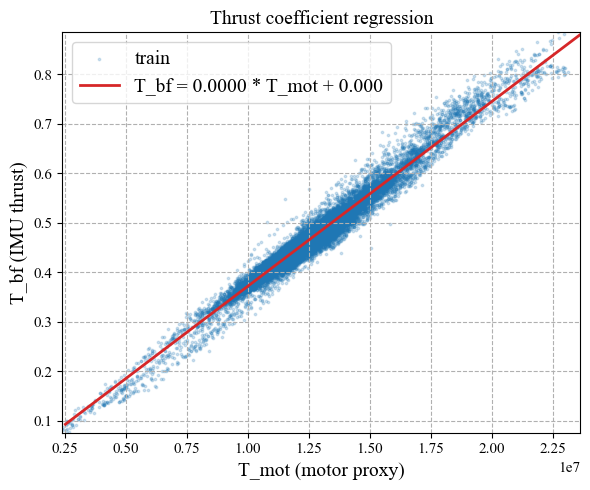

In [24]:
from sklearn.linear_model import LinearRegression

X_train = df_train["T_mot"].values.reshape(-1, 1)
y_train = df_train["T_bf"].values

reg = LinearRegression(fit_intercept=False).fit(X_train, y_train)

Kf = reg.coef_[0]
bias = reg.intercept_

print("========= Fitted Model ========")
print(f"Kf  = {Kf}")
print(f"bias = {bias}")
print("================================")

plt.figure(figsize=(6,5))
plt.scatter(df_train["T_mot"], df_train["T_bf"], s=3, alpha=0.2, label="train")
#
# # regression line
x_line = np.linspace(df_test["T_mot"].min(), df_test["T_mot"].max(), 200)
y_line = Kf * x_line + bias

plt.plot(x_line, y_line, linewidth=2, label=f"T_bf = {Kf:.4f} * T_mot + {bias:.3f}", c='tab:red')
plt.xlabel("T_mot (motor proxy)")
plt.ylabel("T_bf (IMU thrust)")
plt.title("Thrust coefficient regression")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Validation step:  $J_{xx} \dot{\omega}_x = K_t T$

In [25]:
import numpy as np
import pandas as pd
import scipy.interpolate as si

def compute_torque_signals(df, Kf, L=0.0353):
    """
    df must contain columns:
    t, wx, wy, wz, m1_erpm ... m4_erpm
    """

    t = df["t"].to_numpy()
    dt = 0.01
    wx = df["wx"].to_numpy()
    wy = df["wy"].to_numpy()
    wz = df["wz"].to_numpy()

    # ---------------------------
    # Motor torques (X config)
    # ---------------------------
    m1, m2, m3, m4 = (df[c].to_numpy() for c in [
        "m1_rads2", "m2_rads2", "m3_rads2", "m4_rads2"
    ])

    tau_x_id = L * Kf * ((m3 + m4) - (m1 + m2))
    tau_y_id = L * Kf * ((m2 + m3) - (m1 + m4))
    # NOTE: we skip tau_z (reaction torques) unless you want it

    # ---------------------------
    # Angular accelerations
    # ---------------------------
    wxd = pd.Series(wx).diff() / dt
    wyd = pd.Series(wy).diff() / dt
    wzd = pd.Series(wz).diff() / dt

    out = pd.DataFrame({
        "t": t,
        "tau_x_id": tau_x_id,
        "tau_y_id": tau_y_id,
        "wxd": wxd,
        "wyd": wyd,
        "wzd": wzd
    })

    return out

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

J_xx = 2.3951e-5
L = 0.0353


def plot_torque_comparison(df_real_dict, pattern, Kf,
                           L=L, J_xx=J_xx, figsize=(9,5)):
    """
    Compute and plot τ_x comparison for all runs containing `pattern`.

    Produces:
        - Mean ± std envelope for measured τ_x = J_xx * wx_dot
        - Mean ± std envelope for identified τ_x = L*Kf*(...)
        - Uses time t on the x-axis (aligned/truncated)
    """

    outs = []
    ts = []

    # ---------------------------------------------------------------
    # 1) Collect torque signals for all runs matching pattern
    # ---------------------------------------------------------------
    for k, df in df_real_dict.items():
        if pattern.lower() in k.lower():
            out = compute_torque_signals(df, Kf=Kf, L=L)
            out["tau_x_meas"] = J_xx * out["wxd"]
            outs.append(out[["t", "tau_x_meas", "tau_x_id"]])

    if len(outs) == 0:
        print(f"No runs found matching pattern: '{pattern}'")
        return

    # ---------------------------------------------------------------
    # 2) Align lengths by truncating to the shortest run
    # ---------------------------------------------------------------
    min_len = min(len(o) for o in outs)
    outs = [o.iloc[:min_len].reset_index(drop=True) for o in outs]

    # All runs share the same x-axis now
    t = outs[0]["t"].to_numpy()

    # ---------------------------------------------------------------
    # 3) Stack into matrices [N_runs × N_samples]
    # ---------------------------------------------------------------
    meas_stack = np.stack([o["tau_x_meas"].to_numpy() for o in outs], axis=0)
    id_stack   = np.stack([o["tau_x_id"].to_numpy() for o in outs], axis=0)

    # ---------------------------------------------------------------
    # 4) Mean & std
    # ---------------------------------------------------------------
    meas_mean = meas_stack.mean(axis=0)
    meas_std  = meas_stack.std(axis=0)

    id_mean = id_stack.mean(axis=0)
    id_std  = id_stack.std(axis=0)

    # ---------------------------------------------------------------
    # 5) Plot: Torque comparison
    # ---------------------------------------------------------------
    plt.figure(figsize=figsize)

    # Measured torque (J_xx * ω̇ₓ)
    plt.plot(t, meas_mean, label=r"Measured  $\tau_x = J_{xx}\,\dot{\omega}_x$")
    plt.fill_between(t,
                     meas_mean - meas_std,
                     meas_mean + meas_std,
                     alpha=0.25)

    # Identified torque (L Kf (...) )
    plt.plot(t, id_mean, label=r"Identified $\tau_x = L\,K_f\,(\Omega_3^2+\Omega_4^2-\Omega_1^2-\Omega_2^2)$")
    plt.fill_between(t,
                     id_mean - id_std,
                     id_mean + id_std,
                     alpha=0.25)

    plt.xlabel("Time [s]")
    plt.ylabel("Torque [Nm]")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

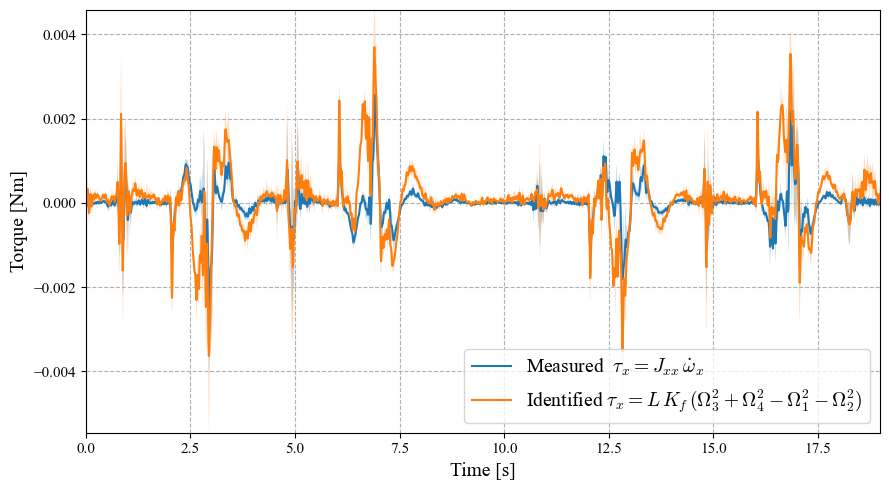

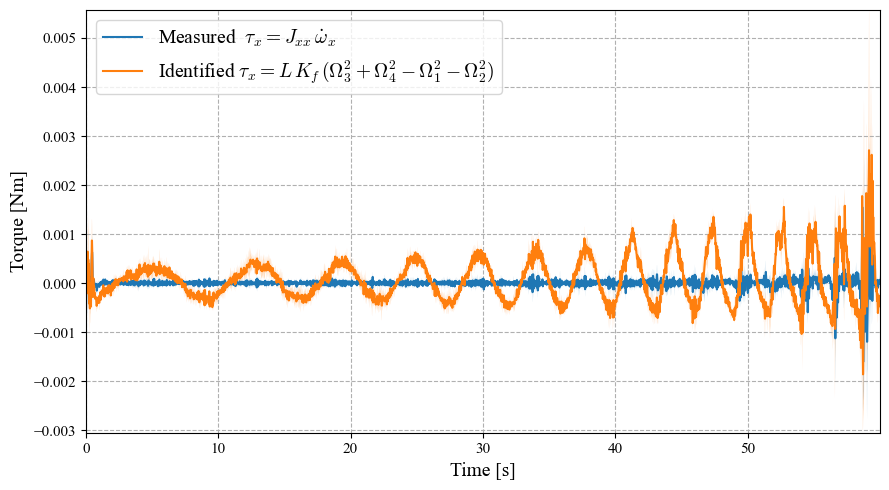

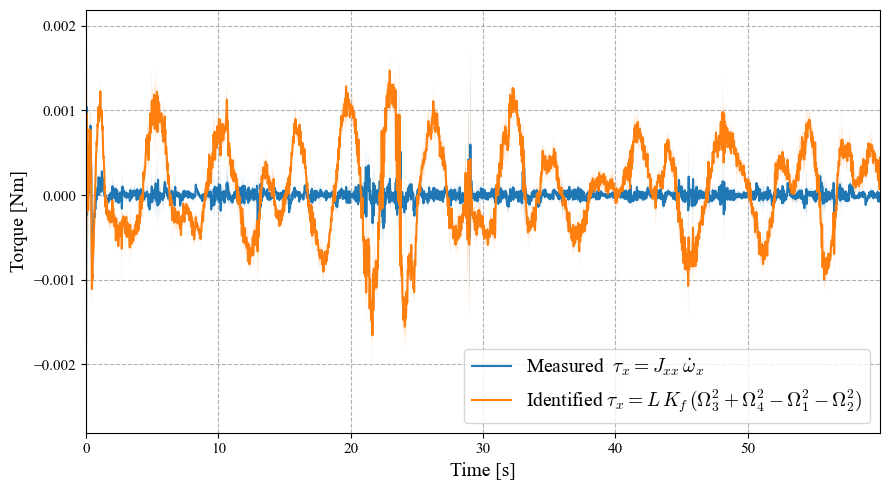

In [27]:
plot_torque_comparison(df_real_dict, pattern="square", Kf=Kf)
plot_torque_comparison(df_real_dict, pattern="chirp", Kf=Kf)
plot_torque_comparison(df_real_dict, pattern="random", Kf=Kf)